In [1]:

import pandas as pd
import numpy as np
import dask.dataframe as dd
from dask.distributed import Client
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error
import lightgbm as lgb
import joblib
import warnings
import optuna  # <--- AÑADIR ESTA LÍNEA
warnings.filterwarnings('ignore')

print("imports completados")

Todos los imports completados ✅


In [2]:
# Configurar Dask (MODIFICADO - Desactivamos el Client)
# try:
#     client = Client(n_workers=2, threads_per_worker=2, memory_limit='4GB')
#     print("Dask configurado ")
# except:
#     print("Usando pandas directamente (Dask opcional)")


✅ Usando el scheduler por defecto de Dask (sin Client).
   Esto usará toda la RAM (16GB) y es crucial para el siguiente paso.


In [3]:
import os

train_path = "/kaggle/input/smadex-challenge-predict-the-revenue/train/train"
test_path = "/kaggle/input/smadex-challenge-predict-the-revenue/test/test"

print("Cargando datos de forma optimizada...")

columns_to_use = [
    'row_id', 'advertiser_bundle', 'advertiser_category', 'advertiser_subcategory',
    'country', 'region', 'dev_make', 'dev_os', 'dev_osv', 'weekday',
    'hour', 'release_msrp', 'avg_act_days', 'wifi_ratio', 
    'weekend_ratio', 'weeks_since_first_seen', 'iap_revenue_d7',
    
    # --- Columnas Complejas (Mapas y Listas) ---
    'cpm',                     # Mapa: {'rewarded': X, 'interstitial': Y, ...}
    'ctr',                     # Mapa: {'rewarded': X, ...}
    'bundles_ins',             # Lista: [bundle1, bundle2, ...]
    'iap_revenue_usd_bundle',  # Mapa: {bundle_id: revenue, ...}
    'num_buys_bundle',         # Mapa: {bundle_id: num_buys, ...}
    'user_bundles',             # Lista: [bundle1, bundle2, ...]

    'iap_revenue_usd_category', # Mapa: {('cat', 'subcat'): revenue, ...}
    'num_buys_category',        # Mapa: {('cat', 'subcat'): num_buys, ...}
    'country_hist'              # Mapa: {'country_code': count, ...}
]
# ----------------------------------------------

ddf_train = dd.read_parquet(train_path, engine='pyarrow')
available_columns = [col for col in columns_to_use if col in ddf_train.columns]
print(f"Columnas disponibles: {available_columns}")

# Recargar solo con las columnas necesarias
ddf_train = dd.read_parquet(train_path, columns=available_columns, engine='pyarrow')
ddf_test = dd.read_parquet(test_path, columns=[col for col in available_columns if col != 'iap_revenue_d7'], engine='pyarrow')

print(f"Forma del train: {ddf_train.shape[0].compute():,}")
print(f"Forma del test: {ddf_test.shape[0].compute():,}")
print("Datos cargados")

Cargando datos de forma optimizada...
Columnas disponibles: ['row_id', 'advertiser_bundle', 'advertiser_category', 'advertiser_subcategory', 'country', 'region', 'dev_make', 'dev_os', 'dev_osv', 'weekday', 'hour', 'release_msrp', 'avg_act_days', 'wifi_ratio', 'weekend_ratio', 'weeks_since_first_seen', 'iap_revenue_d7', 'cpm', 'ctr', 'bundles_ins', 'iap_revenue_usd_bundle', 'num_buys_bundle', 'user_bundles', 'iap_revenue_usd_category', 'num_buys_category', 'country_hist']
Forma del train: 20,600,580
Forma del test: 13,188,409
Datos cargados ✅


In [4]:
print("Información básica del dataset:")
print(f"Columnas: {ddf_train.columns.tolist()}")
print(f"Número de columnas: {len(ddf_train.columns)}")

#  mínima para exploración
sample_info = ddf_train.head(2)
print("\nMuestra de datos:")
print(sample_info)

#  de tipos de datos
print("\nTipos de datos:")
print(ddf_train.dtypes)

Información básica del dataset:
Columnas: ['row_id', 'advertiser_bundle', 'advertiser_category', 'advertiser_subcategory', 'country', 'region', 'dev_make', 'dev_os', 'dev_osv', 'weekday', 'hour', 'release_msrp', 'avg_act_days', 'wifi_ratio', 'weekend_ratio', 'weeks_since_first_seen', 'iap_revenue_d7', 'cpm', 'ctr', 'bundles_ins', 'iap_revenue_usd_bundle', 'num_buys_bundle', 'user_bundles', 'iap_revenue_usd_category', 'num_buys_category', 'country_hist']
Número de columnas: 26

Muestra de datos:
                                 row_id  \
0  819ecc0e-1a97-43ed-83f6-b9ede4f7fc48   
1  0a7fbf18-5041-42af-bd0a-0cb6586b8598   

                          advertiser_bundle advertiser_category  \
0  26fc75598f3a2e63782b4166883034072c49b4aa                game   
1  7eaeef21e215654ea75a5ef78692d1f8ffd0ca54       sport betting   

  advertiser_subcategory country region dev_make   dev_os dev_osv  weekday  \
0             skill game      us   <NA>  generic  android  16.0.0        3   
1           

In [5]:
#features complejos
def create_basic_features_optimized(df):
    """Crear features básicos de forma optimizada"""
    features = df.copy()
    
    categorical_features = [
        'advertiser_bundle', 'advertiser_category', 'advertiser_subcategory',
        'country', 'region', 'dev_make', 'dev_os', 'dev_osv', 'weekday'
    ]
    
    numeric_features = [
        'hour', 'release_msrp', 'avg_act_days', 'wifi_ratio', 
        'weekend_ratio', 'weeks_since_first_seen'
    ]
    
    complex_features = [
        'cpm', 'ctr', 'bundles_ins', 'iap_revenue_usd_bundle', 
        'num_buys_bundle', 'user_bundles'
    ]
    
    keep_cols = ['iap_revenue_d7', 'row_id']
    
    available_cat = [col for col in categorical_features if col in df.columns]
    available_num = [col for col in numeric_features if col in df.columns]
    available_complex = [col for col in complex_features if col in df.columns]
    available_keep = [col for col in keep_cols if col in df.columns] # <-- AÑADIDO
    
    selected_columns = available_cat + available_num + available_complex + available_keep # <-- MODIFICADO
    feature_df = df[selected_columns].copy()
    
    return feature_df, available_cat, available_num, available_complex, available_keep

print("Función de features optimizada (v3) definida")

Función de features optimizada (v3) definida ✅


In [6]:
def unpack_placement_map(df, col_name, new_num_cols_list):
    placements = ['rewarded', 'interstitial', 'banner']
    data = df[col_name].fillna({})
    
    for p in placements:
        new_col = f"{col_name}_{p}"
        df[new_col] = data.apply(lambda x: x.get(p, 0) if isinstance(x, dict) else 0)
        if new_col not in new_num_cols_list:
            new_num_cols_list.append(new_col)
    
    values_list = data.apply(lambda x: list(x.values()) if isinstance(x, dict) else [])
    df[f'{col_name}_total'] = values_list.apply(lambda x: sum(x) if x else 0)
    df[f'{col_name}_max'] = values_list.apply(lambda x: max(x) if x else 0)
    
    for stat in ['total', 'max']:
        if f'{col_name}_{stat}' not in new_num_cols_list:
            new_num_cols_list.append(f'{col_name}_{stat}')
    return df

def unpack_list_col(df, col_name, new_num_cols_list):
    new_col = f"{col_name}_count"
    df[new_col] = df[col_name].apply(lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0)
    if new_col not in new_num_cols_list:
        new_num_cols_list.append(new_col)
    return df

def unpack_value_map(df, col_name, new_num_cols_list):
    data = df[col_name].fillna({})
    values_list = data.apply(lambda x: list(x.values()) if isinstance(x, dict) else [])
    
    df[f'{col_name}_sum'] = values_list.apply(lambda x: sum(x) if x else 0)
    df[f'{col_name}_mean'] = values_list.apply(lambda x: np.mean(x) if x else 0)
    df[f'{col_name}_max'] = values_list.apply(lambda x: max(x) if x else 0)
    df[f'{col_name}_median'] = values_list.apply(lambda x: np.median(x) if x else 0)
    df[f'{col_name}_std'] = values_list.apply(lambda x: np.std(x) if len(x) > 1 else 0)
    df[f'{col_name}_count'] = values_list.apply(lambda x: len(x))
    
    for stat in ['sum', 'mean', 'max', 'median', 'std', 'count']:
        if f'{col_name}_{stat}' not in new_num_cols_list:
            new_num_cols_list.append(f'{col_name}_{stat}')
    return df

def unpack_category_map(df, col_name, new_num_cols_list):
    data = df[col_name].fillna({})
    values_list = data.apply(lambda x: list(x.values()) if isinstance(x, dict) else [])

    df[f'{col_name}_sum'] = values_list.apply(lambda x: sum(x) if x else 0)
    df[f'{col_name}_mean'] = values_list.apply(lambda x: np.mean(x) if x else 0)
    df[f'{col_name}_count'] = values_list.apply(lambda x: len(x))

    for stat in ['sum', 'mean', 'count']:
        if f'{col_name}_{stat}' not in new_num_cols_list:
            new_num_cols_list.append(f'{col_name}_{stat}')
    return df

def unpack_histogram(df, col_name, new_num_cols_list):
    data = df[col_name].fillna({})
    new_col = f"{col_name}_unique_count"
    df[new_col] = data.apply(lambda x: len(x.keys()) if isinstance(x, dict) else 0)
    if new_col not in new_num_cols_list:
        new_num_cols_list.append(new_col)
    return df


def create_enhanced_features(df):
    X, cat_cols, num_cols, complex_cols, keep_cols = create_basic_features_optimized(df)

    if 'cpm' in complex_cols:
        X = unpack_placement_map(X, 'cpm', num_cols)
    if 'ctr' in complex_cols:
        X = unpack_placement_map(X, 'ctr', num_cols)
    if 'bundles_ins' in complex_cols:
        X = unpack_list_col(X, 'bundles_ins', num_cols)
    if 'user_bundles' in complex_cols:
        X = unpack_list_col(X, 'user_bundles', num_cols)
    if 'iap_revenue_usd_bundle' in complex_cols:
        X = unpack_value_map(X, 'iap_revenue_usd_bundle', num_cols)
    if 'num_buys_bundle' in complex_cols:
        X = unpack_value_map(X, 'num_buys_bundle', num_cols)
    if 'iap_revenue_usd_category' in complex_cols:
        X = unpack_category_map(X, 'iap_revenue_usd_category', num_cols)
    if 'num_buys_category' in complex_cols:
        X = unpack_category_map(X, 'num_buys_category', num_cols)
    if 'country_hist' in complex_cols:
        X = unpack_histogram(X, 'country_hist', num_cols)

    if 'iap_revenue_usd_bundle_sum' in X.columns and 'num_buys_bundle_sum' in X.columns:
        X['revenue_per_buy'] = X['iap_revenue_usd_bundle_sum'] / (X['num_buys_bundle_sum'] + 1e-6)
        num_cols.append('revenue_per_buy')
    
    if 'cpm_total' in X.columns and 'ctr_total' in X.columns:
        X['monetization_efficiency'] = X['cpm_total'] / (X['ctr_total'] + 1e-6)
        num_cols.append('monetization_efficiency')
    
    if 'bundles_ins_count' in X.columns and 'user_bundles_count' in X.columns:
        X['bundle_diversity'] = X['bundles_ins_count'] + X['user_bundles_count']
        num_cols.append('bundle_diversity')
    
    if 'advertiser_category' in X.columns and 'country' in X.columns:
        X['cat_country_interaction'] = X['advertiser_category'].astype(str) + '_' + X['country'].astype(str)
        cat_cols.append('cat_country_interaction')
    
    if 'weekend_ratio' in X.columns and 'hour' in X.columns:
        X['hour_numeric'] = pd.to_numeric(X['hour'], errors='coerce').fillna(0)
        X['weekend_hour'] = X['weekend_ratio'] * X['hour_numeric']
        num_cols.append('weekend_hour')
        X['hour'] = X['hour_numeric']
        X = X.drop(columns=['hour_numeric'])
    
    if 'release_msrp' in X.columns:
        X['device_price_cat'] = pd.cut(X['release_msrp'], 
                                        bins=[-1, 200, 500, 1000, 5000], 
                                        labels=['low', 'mid', 'high', 'premium'])
        X['device_price_cat'] = X['device_price_cat'].astype(str)
        cat_cols.append('device_price_cat')
    
    X = X.drop(columns=complex_cols, errors='ignore')
    return X, cat_cols, num_cols, keep_cols

def impute_data(X, cat_cols, num_cols):
    CATEGORIC_IMPUTATIONS = 'Desconocido'
    NUMERIC_IMPUTATIONS = {
        'avg_act_days': 0, 'wifi_ratio': 0, 
        'weekend_ratio': 0, 'weeks_since_first_seen': 0,
    }

    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].fillna(CATEGORIC_IMPUTATIONS)

    if 'hour' in num_cols:
        X['hour'] = pd.to_numeric(X['hour'], errors='coerce').fillna(0)

    if 'release_msrp' in num_cols:
        median_val = X['release_msrp'].median()
        if pd.isna(median_val):
            median_val = 0
        X['release_msrp'] = X['release_msrp'].fillna(median_val)
    
    for col in num_cols:
        if col in NUMERIC_IMPUTATIONS:
            X[col] = X[col].fillna(NUMERIC_IMPUTATIONS[col])
        elif col not in ['hour', 'release_msrp']: 
            X[col] = X[col].fillna(0)
    return X

def process_partition(df):
    X, cat_cols, num_cols, keep_cols = create_enhanced_features(df)
    X = impute_data(X, cat_cols, num_cols)
    return X



dummy_sample = ddf_train.head(5)
meta_df = process_partition(dummy_sample)

ddf_processed = ddf_train.map_partitions(process_partition, meta=meta_df)

print("\n ejecución del pipeline (Lazy)...")
sample_fraction = 0.6
# ----------------------------------------------------
ddf_sampled = ddf_processed.sample(frac=sample_fraction, random_state=42)

print(f"  Ejecutando pipeline y guardando {sample_fraction*100:.0f}% de muestra en disco...")
ddf_sampled.to_parquet('/kaggle/working/train_processed_sample.parquet', write_index=False, engine='pyarrow')

train_sample = pd.read_parquet('/kaggle/working/train_processed_sample.parquet')

y = np.log1p(train_sample.pop('iap_revenue_d7'))
X = train_sample.drop(columns=['row_id'], errors='ignore') 


_, cat_cols_final, num_cols_final, _ = create_enhanced_features(meta_df.drop(columns=['iap_revenue_d7', 'row_id'], errors='ignore'))
cat_cols_final = [col for col in cat_cols_final if col in X.columns]
num_cols_final = [col for col in num_cols_final if col in X.columns]

X = X[cat_cols_final + num_cols_final]
# --------------------------------------------------

if 'release_msrp' in X.columns:
    release_msrp_median = X['release_msrp'].median()
else:
    release_msrp_median = 0
print(f"  Mediana global de 'release_msrp' guardada: {release_msrp_median}")

print(f"\nFeatures categóricas finales: {len(cat_cols_final)}")
print(f"Features numéricas finales: {len(num_cols_final)}")
print(f"Shape final de X: {X.shape}")
print("Datos preparados")

🧠 Definiendo funciones de procesamiento (AVANZADAS)...
🚀 Preparando el pipeline de Dask (FE Avanzado)...
  Calculando 'meta' (estructura de salida)...
  'meta' calculada con éxito.

🧬 Preparando la ejecución del pipeline (Lazy)...
  Ejecutando pipeline y guardando 60% de muestra en disco...
  (Esto tardará un poco más, pero vale la pena...)
  ✅ Muestra procesada guardada en disco.
  Cargando muestra procesada en Pandas...
  ✅ Muestra cargada: 12,360,353 filas

📋 Definiendo listas de features finales...
  Mediana global de 'release_msrp' guardada: 279.0

Features categóricas finales: 11
Features numéricas finales: 7
Shape final de X: (12360353, 18)
Datos preparados ✅


In [7]:
#Label Encoding
print("Aplicando Label Encoding...")
label_encoders = {}
for col in cat_cols_final:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
    else:
        print(f"Advertencia: {col} no encontrada en X para Label Encoding.")

print("Label encoding completado ")

Aplicando Label Encoding...
Label encoding completado ✅


In [8]:
#split de datos
print("Dividiendo datos en train/validation...")
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print("Split completado ")

Dividiendo datos en train/validation...
Train: (9888282, 18), Val: (2472071, 18)
Split completado ✅


In [9]:
#parámetros de LightGBM
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'random_state': 42
}

print("Parámetros de LightGBM configurados ")

Parámetros de LightGBM configurados ✅


In [10]:
# datasets con feature_pre_filter=False
print("Creando datasets para LightGBM (con feature_pre_filter=False)...")

# error de min_data_in_leaf en Optuna
dataset_params = {
    'feature_pre_filter': False
}

train_data = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=cat_cols_final,
    free_raw_data=False,
    params=dataset_params
)

val_data = lgb.Dataset(
    X_val, label=y_val,
    categorical_feature=cat_cols_final,
    free_raw_data=False,
    params=dataset_params
)

print("Datasets creados ")

Creando datasets para LightGBM (con feature_pre_filter=False)...
Datasets creados ✅


In [11]:
print("Entrenando modelo LightGBM FINAL con parámetros optimizados..")

best_params_hardcoded = {
    'learning_rate': 0.019,

-
    'num_leaves': 64,
    'min_child_samples': 120,
    'max_depth': 10,
    'reg_alpha': 0.0804583769258401,
    'reg_lambda': 1.714192858887065,
    'feature_fraction': 0.690552663371603,
    'bagging_fraction': 0.9988279420347322,
    'bagging_freq': 6
}

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbose': 1,
    'random_state': 42
}

lgb_params.update(best_params_hardcoded)

print("Parámetros finales a usar:")
print(lgb_params)

print("\nIniciando entrenamiento final...")

model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=2000,
    valid_sets=[val_data],
    valid_names=['validation'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(50)
    ]
)

print("Modelo final (regularizado) entrenado ")
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbose': 1,
    'random_state': 42
}

lgb_params.update(best_params_hardcoded)

print("Parámetros finales a usar:")
print(lgb_params)

print("\nIniciando entrenamiento final...")

model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=2000,  # <--- AUMENTAR de 1000 a 2000
    valid_sets=[val_data],
    valid_names=['validation'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True), # <--- AUMENTAR de 50 a 100
        lgb.log_evaluation(50)
    ]
)

print("Modelo final entrenado ")

Entrenando modelo LightGBM FINAL con parámetros optimizados (cargados manualmente)...
Entrenando modelo LightGBM FINAL con parámetros MÁS REGULARIZADOS...
Parámetros finales a usar:
{'objective': 'regression', 'metric': 'rmse', 'verbose': 1, 'random_state': 42, 'learning_rate': 0.019, 'num_leaves': 64, 'min_child_samples': 120, 'max_depth': 10, 'reg_alpha': 0.0804583769258401, 'reg_lambda': 1.714192858887065, 'feature_fraction': 0.690552663371603, 'bagging_fraction': 0.9988279420347322, 'bagging_freq': 6}

Iniciando entrenamiento final...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.868418 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3503
[LightGBM] [Info] Number of 

In [12]:

def safe_msle(y_true_orig, y_pred_orig):
    y_pred_orig = np.maximum(y_pred_orig, 0)
    return mean_squared_log_error(y_true_orig, y_pred_orig)

print("Evaluando modelo...")
y_pred_log = model.predict(X_val)

y_val_orig = np.expm1(y_val)
y_pred_orig = np.expm1(y_pred_log)

msle_score = safe_msle(y_val_orig, y_pred_orig)
rmse_score_calc = np.sqrt(msle_score)
print(f" MSLE en validation (Calculado correctamente): {msle_score:.6f}")
print(f" RMSLE en validation (Calculado correctamente): {rmse_score_calc:.6f}")
print(f"   (Score RMSE del modelo en Celda 11: {model.best_score['validation']['rmse']:.6f})")
print("   (Estos dos RMSLE deben ser casi idénticos)")

# Análisis más detallado (ahora sobre la escala original)
print(f"\nEstadísticas de predicciones (en USD originales):")
print(f"True  - Min: {y_val_orig.min():.4f}, Mean: {y_val_orig.mean():.4f}, Max: {y_val_orig.max():.4f}")
print(f"Pred  - Min: {y_pred_orig.min():.4f}, Mean: {y_pred_orig.mean():.4f}, Max: {y_pred_orig.max():.4f}")

Evaluando modelo...
✅ MSLE en validation (Calculado correctamente): 0.169495
✅ RMSLE en validation (Calculado correctamente): 0.411698
   (Score RMSE del modelo en Celda 11: 0.411716)
   (Estos dos RMSLE deben ser casi idénticos)

📊 Estadísticas de predicciones (en USD originales):
True  - Min: 0.0000, Mean: 1.2208, Max: 170465.7000
Pred  - Min: -0.3457, Mean: 0.1004, Max: 126.2059


Calculando feature importance...


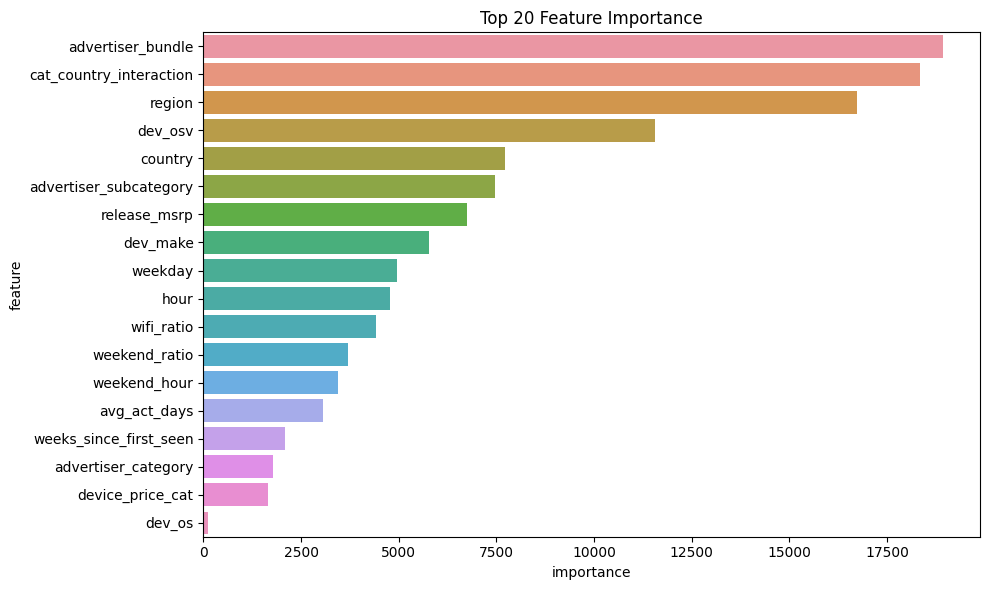

Feature importance calculada ✅


In [13]:
print("Calculando feature importance...")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

print("Feature importance calculada ")

In [ ]:

print("Iniciando predicción en lotes (FE Avanzado)...")

print("  Calculando 'meta' del test...")
dummy_test = ddf_test.head(5)
meta_test = process_partition(dummy_test)
meta_test = meta_test.drop(columns=['row_id'], errors='ignore')
print("  'meta' del test calculada.")

def impute_partition_test(df, cat_cols, num_cols):
    CATEGORIC_IMPUTATIONS = 'Desconocido'
    NUMERIC_IMPUTATIONS = {
        'avg_act_days': 0, 'wifi_ratio': 0, 
        'weekend_ratio': 0, 'weeks_since_first_seen': 0,
    }
    
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].fillna(CATEGORIC_IMPUTATIONS)
            
    if 'hour' in num_cols:
        df['hour'] = pd.to_numeric(df['hour'], errors='coerce').fillna(0)
    
    if 'release_msrp' in num_cols:
        df['release_msrp'] = df['release_msrp'].fillna(release_msrp_median)
    
    for col in num_cols:
        if col in NUMERIC_IMPUTATIONS:
            df[col] = df[col].fillna(NUMERIC_IMPUTATIONS[col])
        elif col not in ['hour', 'release_msrp']: 
            df[col] = df[col].fillna(0)
    return df

def predict_partition(df):
    
    CATEGORIC_IMPUTATIONS = 'Desconocido'
    
    if df.empty:
        return pd.DataFrame(columns=['row_id', 'prediction'])

    row_ids = df['row_id']
    
    # 1. Crear Features
    X_batch, batch_cat_cols, batch_num_cols, _ = create_enhanced_features(df)
    
    # 2.Imputar (Usando la mediana global)
    if 'release_msrp' in X_batch.columns:
         X_batch['release_msrp'] = X_batch['release_msrp'].fillna(release_msrp_median)
    
    for col in batch_num_cols:
        if col in X_batch.columns:
            X_batch[col] = X_batch[col].fillna(0)
    for col in batch_cat_cols:
        if col in X_batch.columns:
            X_batch[col] = X_batch[col].fillna(CATEGORIC_IMPUTATIONS)

    # 3. Label Encoding
    for col in batch_cat_cols:
        if col in X_batch.columns and col in label_encoders:
            le = label_encoders[col]
            X_batch[col] = X_batch[col].astype(str)
            unseen_mask = ~X_batch[col].isin(le.classes_)
            
            if CATEGORIC_IMPUTATIONS not in le.classes_:
                le_classes_list = le.classes_.tolist()
                le_classes_list.append(CATEGORIC_IMPUTATIONS)
                le.classes_ = np.array(le_classes_list)
                
            X_batch.loc[unseen_mask, col] = CATEGORIC_IMPUTATIONS

            if 'Desconocido' not in le.classes_:
                 X_batch.loc[unseen_mask, col] = le.classes_[0]

            X_batch[col] = le.transform(X_batch[col])
        elif col in X_batch.columns:
             X_batch[col] = 0 # Fallback numérico
    
    # 4.Alinear Columnas
    all_cols = cat_cols_final + num_cols_final
    X_batch = X_batch.reindex(columns=all_cols, fill_value=0)
    
    #5.Predecir
    log_predictions = model.predict(X_batch)
    predictions = np.expm1(log_predictions)
    predictions = np.maximum(predictions, 0)
    
    result_df = pd.DataFrame({
        'row_id': row_ids,
        'prediction': predictions
    })
    return result_df

# 4. Aplicar la predicción
print("  Aplicando pipeline de predicción a ddf_test (lazy)...")
meta_pred = pd.DataFrame({'row_id': pd.Series(dtype='str'), 'prediction': pd.Series(dtype='float64')})

results_ddf = ddf_test.map_partitions(predict_partition, meta=meta_test)

print("  Ejecutando .compute() para obtener predicciones...")
results_df = results_ddf.compute()

print(f"Procesamiento completado: {len(results_df):,} predicciones")

# 6. Crear submission
print("Creando archivo de submission...")
submission = results_df.rename(columns={'prediction': 'iap_revenue_d7'})

total_test_rows = ddf_test.shape[0].compute()
if len(submission) != total_test_rows:
    print(f"ERROR: El submission final tiene {len(submission)} filas pero se esperaban {total_test_rows}")
    all_test_ids = ddf_test['row_id'].compute()
    submission = submission.set_index('row_id').reindex(all_test_ids).fillna(0).reset_index()
    print(f"  Submission corregido a {len(submission)} filas.")
else:
    print(f" Submission tiene las {total_test_rows:,} filas requeridas")

print(f" Submission final creado: {submission.shape}")
print(f" Estadísticas de predicciones:")
print(submission['iap_revenue_d7'].describe())

submission_file = '/kaggle/working/submission.csv'
submission.to_csv(submission_file, index=False)
print(f" Submission guardado: {submission_file}")

🤖 Iniciando predicción en lotes (FE Avanzado)...
  Calculando 'meta' del test...


In [ ]:
print("Verificando submission generado...")

# Leer el submission que ya creamos
submission = pd.read_csv('/kaggle/working/submission.csv')

print(f"\nSubmission cargado:")
print(f"   Filas: {len(submission):,}")
print(f"   Columnas: {list(submission.columns)}")

print(f"\n Estadísticas de predicciones:")
print(submission['iap_revenue_d7'].describe())

print(f"\n Primeras 10 predicciones:")
print(submission.head(10))

#verificar valores únicos
unique_preds = submission['iap_revenue_d7'].nunique()
print(f"\nValores únicos en predicciones: {unique_preds}")

if unique_preds < 10:
    print("PROBLEMA: Muy pocos valores únicos - el modelo necesita mejorar")
else:
    print(" El modelo tiene buena variabilidad")

In [ ]:
print("Guardando modelo...")
joblib.dump({
    'model': model,
    'label_encoders': label_encoders,
    'cat_cols': cat_cols,
    'num_cols': num_cols
}, '/kaggle/working/smadex_model.pkl')

print("modelo guardado: /kaggle/working/smadex_model.pkl")